In [1]:
%pip install numpy
%pip install matplotlib scipy

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


Shor's factoring algorithm


In [2]:
import sys
import os

# 1. Get the current folder you are in
# 2. Add the 'src' folder to the list of places Python looks
sys.path.append(os.path.abspath('src'))

print("Python is now looking in:", os.path.abspath('src'))

Python is now looking in: /home/f73aeabd-6de4-471d-92a9-1ba552ae6153/Quantum_Algorithms/src


In [3]:
import numpy as np
import scipy
import math
from math import gcd
from fractions import Fraction
from scipy.sparse import csr_matrix, kron, identity

In [4]:
from quantum_algorithms import (
    I, X, Y, Z, H, P0, P1, encrypt_number, decrypt_number, generate_RSA_keys, modinv, 
    iqft, buildSparseCRk, build_x_tothe_z, qubits_for_number, order_finding_state, 
    text_to_numbers, numbers_to_text, encrypt_text, decrypt_text, order_mod, shor_success, 
    test_success_rate, find_factor, Rk, buildSparseCNOT, swap_gate, cont_frac,
    eval_contfrac, eval_contfrac_rational, qft, simulates_shor_algorithm, factor, 
    is_coprime, continued_fraction_expansion, orderFindingSim, doMeasurement
)

## Problem outline

We will use the quantum computer simulator we set up on problem set 2 to implement a classical simulation of Shor's factoring algorithm. The learning goal is to understand the different parts of the factoring algorithm in detail. 

We will focus on the actual quantum part. The exercises on the number theoretic aspects are optional but they can be helpful for understanding what happens in the factoring algorithm.

Note that the developing the entire simulation on your own would be quite time consuming, so we provide some routines for you and made the last part of putting together the entire factoring algorithm optional.

There is a lot of literature on educational material on this topic. For example, what was formerly known as the quiskit textbook can be found here: https://github.com/Qiskit/textbook/tree/main/notebooks/ch-algorithms# This is a collection of tutorial style jupyter notebooks, which also includes one on Shor's argorithm. 

In [5]:
# load some useful modules

# standard numerics and linear algebra libraries
import numpy as np  
import numpy.linalg as LA
import scipy.linalg as sciLA

# for making plots
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# measure runtimes
import time as time 

# sparse matrix functions
import scipy.sparse as sparse

# avoid typing np.XY all the time
from numpy import (array, pi, cos, sin, ones, size, sqrt, real, mod, append, arange, exp)

import math
from fractions import Fraction

%matplotlib inline

### RSA

As a warm up we implement the RSA encryption scheme. 
Write functions that, given two prime numbers $p$ and $q$ and a number $e<\phi(pq)$, generate a public and a private key.
Note that often, Carmichael's function $\lambda(pq)$ is used in instead of Euler's function. $\lambda(N)$ is defined as the smallest number $r$ for which $a^r=1\,\mathrm{mod}N)$ for all $a$ coprime to $N$. Show that the RSA scheme also works in this case.
Also write functions that use these key to encrypt and decrypt a message $m$.
Here $m$ can be a number $<pq$. To encryt an actual text you would first have to split the squence of letters into blocks that can be mapped to numbers and then encrypted blockwise. If you want to have some fun, write functions that encrypt and decrypt text letter wise, and use it to decrypt the word SHOR.

Hints: Useful functions `pow(a,b,N)` (i.e., $a^b\,\mathrm{mod}N$), `math.gcd()`.

As a testing example you may want to generate public and private keys with $p=61$, $q=53$, $e=17$ and encrypt and decrypt the message $m=65$. This is the example given on the wikipedia page on the RSA cryptosystem. Try out examples with N being a products of larger primes.  

If a third party can determine the prime factors of $N$, they can efficiently calculate the private key $d$ and thus decrypt the message. The security of the protocol thus relies on factoring being a hard problem classically. Thus, being able to factor $N$ efficiently with a quantum computer would break the RSA scheme.

In [6]:
# Example test
p = 104729  
q = 1299709 
e = 65537   
m = 1234567 

public_key, private_key = generate_RSA_keys(p, q, e)
cipher = encrypt_number(m, public_key)
decrypted = decrypt_number(cipher, private_key)

print("N:",  p*q)
print("Large Ciphertext:",  cipher)
print("Verification:",  m == decrypted)
print("Decrypted:", decrypted )
print("Public key:", public_key)
print("Public key(0):", public_key[0])
print("Public key(1):", public_key[1])
print("Private key:", private_key)
print("Private key(0):", private_key[0])
print("Private key(1):", private_key[1])

N: 136117223861
Large Ciphertext: 5519660531
Verification: True
Decrypted: 1234567
Public key: (136117223861, 65537)
Public key(0): 136117223861
Public key(1): 65537
Private key: (136117223861, 108704485601)
Private key(0): 136117223861
Private key(1): 108704485601


In [7]:
p, q, e = 61, 53, 17
public_key, private_key = generate_RSA_keys(p, q, e)
message = "HELLO"
cipher = encrypt_text(message, public_key)
plaintext = decrypt_text(cipher, private_key)


print("N:",  p*q)
print("Large Ciphertext:",  cipher)
print("Verification:",  m == decrypted)
print("Decrypted:",  plaintext)
print("Public key:", public_key)
print("Public key(0):", public_key[0])
print("Public key(1):", public_key[1])
print("Private key:", private_key)
print("Private key(0):", private_key[0])
print("Private key(1):", private_key[1])
print("message:", message)

N: 3233
Large Ciphertext: [2369, 1387, 3061, 3061, 2549]
Verification: True
Decrypted: HELLO
Public key: (3233, 17)
Public key(0): 3233
Public key(1): 17
Private key: (3233, 2753)
Private key(0): 3233
Private key(1): 2753
message: HELLO


In [8]:
p = 61
q = 53
e = 17
m = 65
public_key, private_key = generate_RSA_keys(p, q, e)
cipher = encrypt_number(m, public_key)
message = decrypt_number(cipher, private_key)

print("N:",  p*q)
print("Large Ciphertext:",  cipher)
print("Verification:",  m == decrypted)
print("Decrypted:",  plaintext)
print("Public key:", public_key)
print("Public key(0):", public_key[0])
print("Public key(1):", public_key[1])
print("Private key:", private_key)
print("Private key(0):", private_key[0])
print("Private key(1):", private_key[1])
print("message:", message)

N: 3233
Large Ciphertext: 2790
Verification: False
Decrypted: HELLO
Public key: (3233, 17)
Public key(0): 3233
Public key(1): 17
Private key: (3233, 2753)
Private key(0): 3233
Private key(1): 2753
message: 65


In [9]:
p = 104729  
q = 1299709 
e = 65537   
m = 1234567 

public_key, private_key = generate_RSA_keys(p, q, e)
cipher = encrypt_number(m, public_key)
decrypted = decrypt_number(cipher, private_key)

print("N:",  p*q)
print("Large Ciphertext:",  cipher)
print("Verification:",  m == decrypted)
print("Decrypted:",  plaintext)
print("Public key:", public_key)
print("Public key(0):", public_key[0])
print("Public key(1):", public_key[1])
print("Private key:", private_key)
print("Private key(0):", private_key[0])
print("Private key(1):", private_key[1])
print("message:", message)

N: 136117223861
Large Ciphertext: 5519660531
Verification: True
Decrypted: HELLO
Public key: (136117223861, 65537)
Public key(0): 136117223861
Public key(1): 65537
Private key: (136117223861, 108704485601)
Private key(0): 136117223861
Private key(1): 108704485601
message: 65


In [10]:
p = 1013
q = 2027
e = 65537 # Using the most common RSA exponent
m = 123456 # Your message number

public_key, private_key = generate_RSA_keys(p, q, e)
cipher = encrypt_number(m, public_key)
message = decrypt_number(cipher, private_key)

print("N:",  p*q)
print("Large Ciphertext:",  cipher)
print("Verification:",  m == decrypted)
print("Decrypted:",  plaintext)
print("Public key:", public_key)
print("Public key(0):", public_key[0])
print("Public key(1):", public_key[1])
print("Private key:", private_key)
print("Private key(0):", private_key[0])
print("Private key(1):", private_key[1])
print("message:", message)

N: 2053351
Large Ciphertext: 1462141
Verification: False
Decrypted: HELLO
Public key: (2053351, 65537)
Public key(0): 2053351
Public key(1): 65537
Private key: (2053351, 1208657)
Private key(0): 2053351
Private key(1): 1208657
message: 123456


In [11]:
p = 104729  
q = 1299709 
e = 65537   
m = 987654321

cipher = encrypt_number(m, public_key)
message = decrypt_number(cipher, private_key)

print("N:",  p*q)
print("Large Ciphertext:",  cipher)
print("Verification:",  m == decrypted)
print("Decrypted:",  plaintext)
print("Public key:", public_key)
print("Public key(0):", public_key[0])
print("Public key(1):", public_key[1])
print("Private key:", private_key)
print("Private key(0):", private_key[0])
print("Private key(1):", private_key[1])
print("message:", message)

N: 136117223861
Large Ciphertext: 1849223
Verification: False
Decrypted: HELLO
Public key: (2053351, 65537)
Public key(0): 2053351
Public key(1): 65537
Private key: (2053351, 1208657)
Private key(0): 2053351
Private key(1): 1208657
message: 2045841


In [12]:
p = 1913
q = 2127
e = 65537 
m = 123456

cipher = encrypt_number(m, public_key)
message = decrypt_number(cipher, private_key)

print("N:",  p*q)
print("Large Ciphertext:",  cipher)
print("Verification:",  m == decrypted)
print("Decrypted:",  plaintext)
print("Public key:", public_key)
print("Public key(0):", public_key[0])
print("Public key(1):", public_key[1])
print("Private key:", private_key)
print("Private key(0):", private_key[0])
print("Private key(1):", private_key[1])
print("message:", message)

N: 4068951
Large Ciphertext: 1462141
Verification: False
Decrypted: HELLO
Public key: (2053351, 65537)
Public key(0): 2053351
Public key(1): 65537
Private key: (2053351, 1208657)
Private key(0): 2053351
Private key(1): 1208657
message: 123456


In [13]:
p = 1013
q = 2027
e = 65537 
m = 123456

# IMPORTANT: You must run this line to update the keys!
public_key, private_key = generate_RSA_keys(p, q, e)

cipher = encrypt_number(m, public_key)
message = decrypt_number(cipher, private_key)

print("N:",  p*q)
print("Large Ciphertext:",  cipher)
print("Verification:",  m == decrypted)
print("Decrypted:",  plaintext)
print("Public key:", public_key)
print("Public key(0):", public_key[0])
print("Public key(1):", public_key[1])
print("Private key:", private_key)
print("Private key(0):", private_key[0])
print("Private key(1):", private_key[1])

N: 2053351
Large Ciphertext: 1462141
Verification: False
Decrypted: HELLO
Public key: (2053351, 65537)
Public key(0): 2053351
Public key(1): 65537
Private key: (2053351, 1208657)
Private key(0): 2053351
Private key(1): 1208657


In [14]:
p, q, e, m = 61, 53, 17, 65
# 1. Create the keys
public_key, private_key = generate_RSA_keys(p, q, e)

# 2. Use the ENCRYPT function for the ciphertext
ciphertext = encrypt_number(m, public_key)

# 3. Use the DECRYPT function for the plaintext
plaintext = decrypt_number(ciphertext, private_key)

print("N:",  p*q)
print("Large Ciphertext:",  cipher)
print("Verification:",  m == decrypted)
print("Decrypted:",  plaintext)
print("Public key:", public_key)
print("Public key(0):", public_key[0])
print("Public key(1):", public_key[1])
print("Private key:", private_key)
print("Private key(0):", private_key[0])
print("Private key(1):", private_key[1])

N: 3233
Large Ciphertext: 1462141
Verification: False
Decrypted: 65
Public key: (3233, 17)
Public key(0): 3233
Public key(1): 17
Private key: (3233, 2753)
Private key(0): 3233
Private key(1): 2753


In [15]:
p, q, e, m = 101, 151, 17, 211 
public_key, private_key = generate_RSA_keys(p, q, e, use_carmichael=True)

ciphertext = encrypt_number(m, public_key)
plaintext = decrypt_number(ciphertext, private_key)

print("N:",  p*q)
print("Large Ciphertext:",  cipher)
print("Verification:",  m == decrypted)
print("Ciphertext:", ciphertext)
print("Decrypted:",  plaintext)
print("Public key:", public_key)
print("Public key(0):", public_key[0])
print("Public key(1):", public_key[1])
print("Private key:", private_key)
print("Private key(0):", private_key[0])
print("Private key(1):", private_key[1])

N: 15251
Large Ciphertext: 1462141
Verification: False
Ciphertext: 13616
Decrypted: 211
Public key: (15251, 17)
Public key(0): 15251
Public key(1): 17
Private key: (15251, 53)
Private key(0): 15251
Private key(1): 53


In [16]:
word = "SHOR"
cipher_nums = encrypt_text(word, public_key)
print("Cipher numbers:", cipher_nums)

decrypted_word = decrypt_text(cipher_nums, private_key)
print("Decrypted word:", decrypted_word)

print("N:",  p*q)
print("Large Ciphertext:",  cipher)
print("Verification:",  m == decrypted)
print("Decrypted:",  plaintext)
print("Public key:", public_key)
print("Public key(0):", public_key[0])
print("Public key(1):", public_key[1])
print("Private key:", private_key)
print("Private key(0):", private_key[0])
print("Private key(1):", private_key[1])
print("message:", message)

Cipher numbers: [90, 11001, 2026, 2943]
Decrypted word: SHOR
N: 15251
Large Ciphertext: 1462141
Verification: False
Decrypted: 211
Public key: (15251, 17)
Public key(0): 15251
Public key(1): 17
Private key: (15251, 53)
Private key(0): 15251
Private key(1): 53
message: 123456


In [17]:
# Larger primes for a robust modulus N
p = 104729  
q = 1299709 
e = 65537   
m = 987654321
cipher = encrypt_number(m, public_key)
decrypted = decrypt_number(cipher, private_key)

print("N:",  p*q)
print("Large Ciphertext:",  cipher)
print("Verification:",  m == decrypted)
print("Decrypted:",  plaintext)
print("Public key:", public_key)
print("Public key(0):", public_key[0])
print("Public key(1):", public_key[1])
print("Private key:", private_key)
print("Private key(0):", private_key[0])
print("Private key(1):", private_key[1])

N: 136117223861
Large Ciphertext: 10633
Verification: False
Decrypted: 211
Public key: (15251, 17)
Public key(0): 15251
Public key(1): 17
Private key: (15251, 53)
Private key(0): 15251
Private key(1): 53


### Success of the factoring algoithm

In the factoring algorithm, given a number $N$ of which we want to find a factor, one randomly picks a number $1<x<N$ that is coprime with $N$ and determines its order mod $N$. (In fact, we randomly pick a number $1<x<N$ and check if it is coprime wih N. If not, we have aready found a factor of N and can stop.) If the order $r$ is even and the root of $x^{r/2}\neq -1$, then either $x^{r/2}+1$ or $x^{r/2}-1$ must have a common factor with $N$. Hence by calculating $\mathrm{gcd}(x^{r/2}+1,N)$ and $\mathrm{gcd}(x^{r/2}-1,N)$ we find a factor of $N$ and the algorithm succeeds. Here we want to explore for how many randomly chosen $x$ these conditions are fulfilled, thereby learning something about the structure of the multiplicative group of coprimes with $N$. 

- Write a function that finds the order of $x$ mod $N$ in a brute force way (just iteratively multiplying $x$ with itself mod $N$ until one gets 1). This part will in the end be done on the quantum computer.
- Check for how many of the numbers coprime with $N$ does $x^{r/2}\pm 1\, \mathrm{mod}\, N$ have a common factor with $N$, i.e. the factoring algorithm succeeds. Use small $N$ which are a product of two primes for checking, e.g. $N=91$.

In [18]:
# Example test

N = 91
x = 10

success, total, rate = test_success_rate(N)

print("Total coprime x:", total)
print("Successful x:", success)
print("Success rate:", rate)
print("Factor:", find_factor(x, N))

Total coprime x: 71
Successful x: 54
Success rate: 0.7605633802816901
Factor: None


In [19]:
N=55
x=13
 
success, total, rate = test_success_rate(N)

print("Total coprime x:", total)
print("Successful x:", success)
print("Success rate:", rate)
print("Factor:", find_factor(x, N))

Total coprime x: 39
Successful x: 30
Success rate: 0.7692307692307693
Factor: 11


In [20]:
N=203
x=2

success, total, rate = test_success_rate(N)

print("Total coprime x:", total)
print("Successful x:", success)
print("Success rate:", rate)
print("Factor:", find_factor(x, N))

Total coprime x: 167
Successful x: 126
Success rate: 0.7544910179640718
Factor: 7


### The quantum Fourier transform

We now come to the quantum part of the algorithm. The first crucial ingredient of the quantum order finding algorithm is the inverse quantum Fourier transform. 

Below we provide some functions you might have developed in similar form on problem set 2, and which might be useful in the following.

#### (a) Building swap gates and controlled phase gates

- Write a function that builds controlled $R_k$ gates between two arbitrary quibits in a register (using sparse matrices), similar to the CNOT gate you implemented on problem set 2. The single qubit $R_k$ gate is provided above but keep in mind that for the inverse QFT you need $R_k^{-1}=R_k^\dagger$.
- Write a function that builds swap gates between pairs of qubits. Note that a swap gate on two qubits can be written as $U_{\textrm{swap}} = |00\rangle\langle 00|+|01\rangle\langle 10|+|10\rangle\langle 01|+|11\rangle\langle 11|$.

In [21]:
# Example test

# Test 2-qubit CNOT
CR = buildSparseCNOT(n=2, ic=0, it=1)
print("2-qubit CNOT:\n", CR.toarray())

# Test 2-qubit swap
SW = swap_gate(n=2, q1=0, q2=1)
print("2-qubit swap:\n", SW.toarray())


2-qubit CNOT:
 [[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]]
2-qubit swap:
 [[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]]


In [22]:
# Test 4-qubit controlled-Rk
CR = buildSparseCRk(n=4, ic=0, it=2, k=3)
print("4-qubit controlled-Rk:\n", CR.toarray())

# Test 4-qubit swap
SW = swap_gate(n=4, q1=1, q2=3)
print("4-qubit swap:\n", SW.toarray())

4-qubit controlled-Rk:
 [[1.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j        ]
 [0.        +0.j         1.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j        ]
 [0.        +0.j         0.        +0.j         1.        +0.j
  0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j   

#### (b) Fourier transform

Implement the inverse quantum Fourier transform (iQFT). 

Instructions:

Write a function that takes as input the state of the register (i.e. the coefficient vector in the computational basis), sequentially applies all gates of the iQFT circuit, and outputs the final state (coefficient vector) again.
We don't want to build the whole iQFT as a unitary matrix as this matrix would be dense and take up a lot of memory. Applying it to a state would scale as $(2^n)^2$. The sequential application of the $O(n^2)$ sparse gates results in a $O(n^2 2^n)$ scaling, thus you have implemented a version of a classical (inverse) fast Fourier transform!

For the order finding algorithm we will need to apply the iQFT only to the first register. 
Thus, your iQFT function should allow you to apply it only to the first $n_1$ qubits of an $n$-qubit register and leave the remaining qubits alone, i.e. is the identity on the remaining qubits.

Note: In the order finding algorithm, the qubits will be measured right after the iQFT. Thus, as shown on Problem set 3.1, it would be sufficent to measure the qubits sequentially and feed forward the result. This would enable to simulate this part of the order finding algorithm more efficiently, and only using single qubit gates.

In [23]:
# Example test
n = 3
n1 = 2

state = np.zeros(2**n, dtype=complex)
state[3] = 1   # example basis state

final_state = iqft(state, n, n1)

print(final_state)

[ 0.000000e+00+0.j   5.000000e-01+0.j   0.000000e+00+0.j
  3.061617e-17-0.5j  0.000000e+00+0.j  -5.000000e-01+0.j
  0.000000e+00+0.j  -3.061617e-17+0.5j]


In [24]:
# Example test
n = 4
n1 = 3

state = np.zeros(2**n, dtype=complex)
state[3] = 1   # example basis state

final_state = iqft(state, n, n1)

print(final_state)

[ 0.00000000e+00+0.j          3.53553391e-01+0.j
  0.00000000e+00+0.j          2.50000000e-01-0.25j
  0.00000000e+00+0.j          2.16489014e-17-0.35355339j
  0.00000000e+00+0.j         -2.50000000e-01-0.25j
  0.00000000e+00+0.j         -3.53553391e-01+0.j
  0.00000000e+00+0.j         -2.50000000e-01+0.25j
  0.00000000e+00+0.j         -2.16489014e-17+0.35355339j
  0.00000000e+00+0.j          2.50000000e-01+0.25j      ]


In [25]:
n = 7
n1 = 5

state = np.zeros(2**n, dtype=complex)
state[3] = 1   # example basis state

final_state = iqft(state, n, n1)

print(final_state)

[0.       +0.j 0.       +0.j 0.       +0.j 0.1767767+0.j 0.       +0.j
 0.       +0.j 0.       +0.j 0.1767767+0.j 0.       +0.j 0.       +0.j
 0.       +0.j 0.1767767+0.j 0.       +0.j 0.       +0.j 0.       +0.j
 0.1767767+0.j 0.       +0.j 0.       +0.j 0.       +0.j 0.1767767+0.j
 0.       +0.j 0.       +0.j 0.       +0.j 0.1767767+0.j 0.       +0.j
 0.       +0.j 0.       +0.j 0.1767767+0.j 0.       +0.j 0.       +0.j
 0.       +0.j 0.1767767+0.j 0.       +0.j 0.       +0.j 0.       +0.j
 0.1767767+0.j 0.       +0.j 0.       +0.j 0.       +0.j 0.1767767+0.j
 0.       +0.j 0.       +0.j 0.       +0.j 0.1767767+0.j 0.       +0.j
 0.       +0.j 0.       +0.j 0.1767767+0.j 0.       +0.j 0.       +0.j
 0.       +0.j 0.1767767+0.j 0.       +0.j 0.       +0.j 0.       +0.j
 0.1767767+0.j 0.       +0.j 0.       +0.j 0.       +0.j 0.1767767+0.j
 0.       +0.j 0.       +0.j 0.       +0.j 0.1767767+0.j 0.       +0.j
 0.       +0.j 0.       +0.j 0.1767767+0.j 0.       +0.j 0.       +0.j
 0.   

### Quantum order finding

The second ingredient of the order finding algorithm is the modular multiplication gate: $U:\,|y\rangle \mapsto |xy \,\mathrm{mod}\, N\rangle$ (for $y< N$) in second register controlled by some qubit in the first register. For $y\geq N$, $U$ is the identity. This is the "padding" we need since $N$ will not be a power of two. $U^{2^j}$ gates are applied to the second register controlled by the state of qubit $j$ in the first register. When doing this on an actual quantum computer this step would be accomlished by implementing modular exponentiation with reversible classical gates. This requires $O(L^3)$ gates (where $L$ is the number of binary digits of $N$) classically through repeated squaring. 
This is actually the bottleneck of the factoring algorithm and constructing the classical reversible circuits is not trivial.

Here we will make our life easy and directly implement the collective action of the controlled $U^{2^j}$ gates, which is the unitary $U_x :|z\rangle|y\rangle \mapsto |z\rangle|x^zy \,\mathrm{mod}\, N\rangle$ for $y< N$ and $|z\rangle|y\rangle \mapsto |z\rangle|y\rangle$ otherwise. 

#### (a) Modular exponentiation gate

Below you are provided a function that builds the operation $U_x$ as a sparse matrix. The inputs are the number of qubits $t$ in the first register and the integer numbers $x$ and $N$. The resulting matrix only has one non-zero entry in each row. Let us explain more precisely what the structure of the matrix $U_x$ is: It is block diagonal. For a fixed state $|z\rangle$ of the 1st register, there is a $2^L \times 2^L$ block ($L$ being the size of the second register) spanned by the all possible states $| y \rangle$ of the second register. Within each such block in each row there is one non-zero matrix element (with value 1) at position (column) $x^zy \,\mathrm{mod}\, N$ (for $y<N$) with respect to the beginning of the block. For $y\geq N$ the non-zero entry is on the diagonal. 

Make sure you understand how the construction of the $U_x$ gate works and test it for some examples where you can compute the positions of the non-zero matrix elements by hand to test the implemenation.

In [26]:
U=build_x_tothe_z(10, 2, 15)
print("U dense matrices:\n", U.toarray())
print()
print("U sparse matrices:\n", build_x_tothe_z(10, 2, 15))

U dense matrices:
 [[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]]

U sparse matrices:
   (0, 0)	1.0
  (1, 1)	1.0
  (2, 2)	1.0
  (3, 3)	1.0
  (4, 4)	1.0
  (5, 5)	1.0
  (6, 6)	1.0
  (7, 7)	1.0
  (8, 8)	1.0
  (9, 9)	1.0
  (10, 10)	1.0
  (11, 11)	1.0
  (12, 12)	1.0
  (13, 13)	1.0
  (14, 14)	1.0
  (15, 15)	1.0
  (16, 16)	1.0
  (17, 18)	1.0
  (18, 20)	1.0
  (19, 22)	1.0
  (20, 24)	1.0
  (21, 26)	1.0
  (22, 28)	1.0
  (23, 30)	1.0
  (24, 17)	1.0
  :	:
  (16359, 16365)	1.0
  (16360, 16354)	1.0
  (16361, 16358)	1.0
  (16362, 16362)	1.0
  (16363, 16366)	1.0
  (16364, 16355)	1.0
  (16365, 16359)	1.0
  (16366, 16363)	1.0
  (16367, 16367)	1.0
  (16368, 16368)	1.0
  (16369, 16376)	1.0
  (16370, 16369)	1.0
  (16371, 16377)	1.0
  (16372, 16370)	1.0
  (16373, 16378)	1.0
  (16374, 16371)	1.0
  (16375, 16379)	1.0
  (16376, 16372)	1.0
  (16377, 16380)	1.0
  (16378, 16373)	1.0
  (16379, 16381)	1.0
  

In [27]:
# Example test
U=build_x_tothe_z(2, 2, 3)
print("U dense matrices:\n", U.toarray())
print()
print("U sparse matrices:\n", build_x_tothe_z(2, 2, 3))

U dense matrices:
 [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]

U sparse matrices:
   (0, 0)	1.0
  (1, 1)	1.0
  (2, 2)	1.0
  (3, 3)	1.0
  (4, 4)	1.0
  (5, 6)	1.0
  (6, 5)	1.0
  (7, 7)	1.0
  (8, 8)	1.0
  (9, 9)	1.0
  (10, 10)	1.

In [28]:
U=build_x_tothe_z(2, 4, 5)
print("U dense matrices:\n", U.toarray())
print()
print("U sparse matrices:\n", build_x_tothe_z(2, 4, 5))

U dense matrices:
 [[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]

U sparse matrices:
   (0, 0)	1.0
  (1, 1)	1.0
  (2, 2)	1.0
  (3, 3)	1.0
  (4, 4)	1.0
  (5, 5)	1.0
  (6, 6)	1.0
  (7, 7)	1.0
  (8, 8)	1.0
  (9, 12)	1.0
  (10, 11)	1.0
  (11, 10)	1.0
  (12, 9)	1.0
  (13, 13)	1.0
  (14, 14)	1.0
  (15, 15)	1.0
  (16, 16)	1.0
  (17, 17)	1.0
  (18, 18)	1.0
  (19, 19)	1.0
  (20, 20)	1.0
  (21, 21)	1.0
  (22, 22)	1.0
  (23, 23)	1.0
  (24, 24)	1.0
  (25, 28)	1.0
  (26, 27)	1.0
  (27, 26)	1.0
  (28, 25)	1.0
  (29, 29)	1.0
  (30, 30)	1.0
  (31, 31)	1.0


Note: Use sparse matrices (csr_matrix) for memory-efficient and realistic Shor simulations, converting to dense (toarray()) only for small examples, as dense matrices grow exponentially and can quickly exhaust memory. 

#### (b) The order finding algorithm put together

Now implement the quantum order finding algorithm (excluding the final measurement) and use it to find the order of 7 mod 15 and of 2 mod 21. Inputs: t, x, N. Output: The final state of the circuit. 

Analyse the output state: In what states can each one of the registers end up? Visualize the probability distribution over the outcome states. Interpret and discuss your results! The code snippets below give you some ideas on how to do this. 

Try out different $t$ to see how many qubits are needed in the 1st register to get reliable results. Try to verify the expected behavior: In the case $N=15$ the order finding algorithm always gives the exact result because the order is a power of 2. For $N=21$ this is not always the case (what orders $r$ can appear?), meaning that the peaks in the probability distribution over the predicted phases becomes broader when $t$ is decreased.

When the denominator of $s/r$ is not a power of two, the phase can only be estimated approximately. In this case the continued fraction algorithm is used to find the the closest rational with denominator $<N$ from the output $b/2^t$ of the order finding algorithm. Check for which outputs $b$ the correct order $r$ is found. 

The continued fraction algorithm is in principle straight forward to implement (we provide an example at the end of this problem set) but you can as well use the function Fraction() from the fractions module, as done in the snippet below.

In [29]:
# Here are some ideas how to analyze the probability distribution, assuming psi holds the oputput state of the order finding algorithm

# analyse the probabilities
Probs=np.abs(psi**2)

# plot the distribution
plt.semilogy(Probs,'.')

# determine where the peaks are (round small numbers down to zero)
indNZ=np.nonzero(np.round(Probs,2))

L = qubits_for_number(N)
# probable states of the first register 
indNZ_reg1= array(indNZ)//2**L
print(indNZ_reg1)
print(np.round(Probs[indNZ],4)) # values at the peaks
print(sum(Probs[indNZ])) # total of peak values (probability to obtain the closest possible number to s/r, but this is not true in general, depends on how we round)

# probable states of the second register
indNZ_reg2= array(indNZ) % 2**L
print(indNZ_reg2)


# Here is an example of how to obtain the nearest rational number with denominator <N (here N=15)
frac = Fraction(33/256).limit_denominator(15)
print(frac.numerator)
print(frac.denominator)

NameError: name 'psi' is not defined

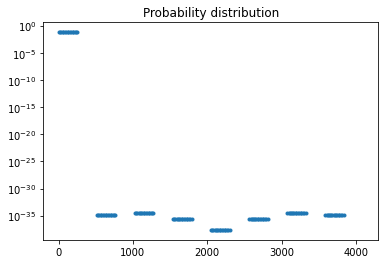

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction

t = 8
x = 7
N = 15

psi = order_finding_state(t,x,N)

Probs = np.abs(psi)**2

plt.semilogy(Probs,'.')
plt.title("Probability distribution")
plt.show()

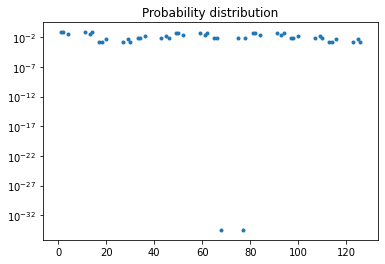

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
t = 4
x = 3
N = 7

psi = order_finding_state(t,x,N)
Probs = np.abs(psi)**2
plt.semilogy(Probs,'.')
plt.title("Probability distribution")
plt.show()

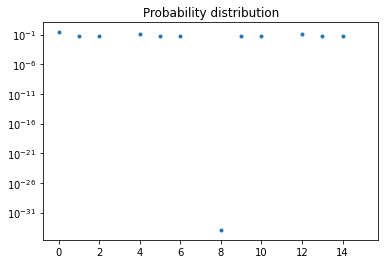

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
t = 2
x = 2
N = 4

psi = order_finding_state(t,x,N)
Probs = np.abs(psi)**2
plt.semilogy(Probs,'.')
plt.title("Probability distribution")
plt.show()

### Factoring algorithm

Now we want to put the whole factoring algorithm together, including measurements.

The functions and pseudocode below will help you with this.

Use your algorithm to factor 21. Play around and try larger numbers and vary the size of the 1st register. How far can you get in terms of the size of N?

Hint: To speed up you simulation you can "cheat" and run the order finding algorithm only once for a given $x$ and use the resulting probability distribution to repeatedly do measurements without re-evaluating the circuit.

In [ ]:
import numpy as np
from math import gcd
import time
from sympy import factorint

N = 21

factor_found = factor(N)
print("Found factor:", factor_found)

```
factoring(inputs):
    determine the size of the second register
    while no factor was found try different values of x
        check if x is coprime with N (if not, then we already have a factor)
        run the order finding algorithm, including the final measurement
        using the result in the first register, use continued fraction to get a guess for r
        while r is not yet the order (and some maximal number of trials has not been exceeded)
            run the order finding algorithm again to get a second estimate r2 for the order
            r=lcm(r, r2)
        if the conditions r even and x^(r/2)!=-1 mod N are fulfilled
            return gcd(x^(r/2) + 1, N) or gcd(x^(r/2) + 1, N) Success!
```

### Continued fraction algorithm

Here is a "manual" implementation of the continued fraction expansion, i.e. a function that takes as input a real number phi and returns a rational approximation of it. The function takes an additional integer input that specifies the maximal value of the denominator of the approximating fraction (i.e. the requested precision). Playing with this may help you to deepen your understanding of continued fractions.

In [33]:
from fractions import Fraction

phi = 9000 / 3527
print("phi =", phi)
max_denom = 200

frac = cont_frac(phi, max_denom)
print("Continued fraction:", frac)
print("Float value:", eval_contfrac(frac))
print("Exact fraction:", eval_contfrac_rational(frac))

frac2 = Fraction(phi).limit_denominator(max_denom)
print("Python Fraction numerator:", frac2.numerator)
print("Python Fraction denominator:", frac2.denominator)

phi = 2.55174369152254
Continued fraction: [2, 1, 1, 4, 3]
Float value: 2.5517241379310347
Exact fraction: [74, 29]
Python Fraction numerator: 74
Python Fraction denominator: 29


In [32]:
phi = 251 / 2048
print("phi =", phi)
max_denom = 200

frac = cont_frac(phi, max_denom)
print("Continued fraction:", frac)
print("Float value:", eval_contfrac(frac))
print("Exact fraction:", eval_contfrac_rational(frac))

frac2 = Fraction(phi).limit_denominator(max_denom)
print("Python Fraction numerator:", frac2.numerator)
print("Python Fraction denominator:", frac2.denominator)

phi = 0.12255859375
Continued fraction: [0, 8, 6, 3]
Float value: 0.12258064516129033
Exact fraction: [19, 155]
Python Fraction numerator: 19
Python Fraction denominator: 155


In [31]:
phi = 944 / 3671
max_denom = 4000

frac = cont_frac(phi, max_denom)
print("Continued fraction:", frac)
print("Float value:", eval_contfrac(frac))
print("Exact fraction:", eval_contfrac_rational(frac))

frac2 = Fraction(phi).limit_denominator(max_denom)
print("Python Fraction numerator:", frac2.numerator)
print("Python Fraction denominator:", frac2.denominator)

Continued fraction: [0, 3, 1, 7, 1, 103, 1]
Float value: 0.25715064015254696
Exact fraction: [944, 3671]
Python Fraction numerator: 944
Python Fraction denominator: 3671


In [30]:
phi = 29036/ 50100
print("phi =", phi)
max_denom = 4117

frac = cont_frac(phi, max_denom)
print("Continued fraction:", frac)
print("Float value:", eval_contfrac(frac))
print("Exact fraction:", eval_contfrac_rational(frac))

frac2 = Fraction(phi).limit_denominator(max_denom)
print("Python Fraction numerator:", frac2.numerator)
print("Python Fraction denominator:", frac2.denominator)

phi = 0.579560878243513
Continued fraction: [0, 1, 1, 2, 1, 1, 1, 3, 1, 7, 1, 1, 2, 3]
Float value: 0.579560878243513
Exact fraction: [7259, 12525]
Python Fraction numerator: 2138
Python Fraction denominator: 3689


### Man vs. machine

Ask Chat GPT to write a python program that simulates Shor's algorithm (I haven't tried). See if what comes out is correct, and if so, check whether your emulator beats it in terms of runtime.

In [ ]:
import numpy as np
from math import gcd
import time
from sympy import factorint

N = 15

start = time.time()
factors = simulates_shor_algorithm(N)
end = time.time()

print("Simulated Shor factors:", factors)
print(f"Time: {end - start:.6f}s")

start = time.time()
classical_factors = list(factorint(N).keys())
end = time.time()

print("Classical factors:", classical_factors)
print(f"Time: {end - start:.6f}s")

In [ ]:
import numpy as np
from math import gcd
import time
from sympy import factorint
import random

# Testing
N = 15
x = np.random.randint(2, N)
start = time.time()
factors = simulates_shor_algorithm(N)
end = time.time()
print("simulates_Shor_algorithm factors:\n", factors)
print(f"Time: {end - start:.6f}s")

# Compare with classical factoring

start = time.time()
classical_factors = list(factorint(N).keys())
end = time.time()
print(f"Classical factors: {classical_factors}")
print(f"Time: {end - start:.6f}s")